In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import time

In [11]:
!pip install curl_cffi

In [12]:
import requests
import pandas as pd
import time

restaurant_name = []
rating = []
cost_for_two = []
cuisine = []
area = []
delivery_time = []
total_ratings = []
restaurant_id = []

url = "https://www.swiggy.com/dapi/restaurants/list/v5"

headers = {
    "User-Agent": "Mozilla/5.0"
}

lat = "18.5204"
lng = "73.8567"

for offset in range(0, 600, 20):   # 600 → gives around 500+ rows
    
    params = {
        "lat": lat,
        "lng": lng,
        "offset": offset,
        "page_type": "DESKTOP_WEB_LISTING"
    }

    response = requests.get(url, headers=headers, params=params)
    data = response.json()

    restaurants = data["data"]["cards"][1]["card"]["card"]["gridElements"]["infoWithStyle"]["restaurants"]

    for r in restaurants:
        info = r["info"]

        restaurant_name.append(info.get("name"))
        rating.append(info.get("avgRating"))
        cost_for_two.append(info.get("costForTwo"))
        cuisine.append(", ".join(info.get("cuisines", [])))
        area.append(info.get("areaName"))
        delivery_time.append(info.get("sla", {}).get("deliveryTime"))
        total_ratings.append(info.get("totalRatingsString"))
        restaurant_id.append(info.get("id"))

    print("Offset scraped:", offset)

    time.sleep(2)   # prevents blocking

df = pd.DataFrame({
    "Restaurant_Name": restaurant_name,
    "Rating": rating,
    "Cost_For_Two": cost_for_two,
    "Cuisine": cuisine,
    "Area": area,
    "Delivery_Time": delivery_time,
    "Total_Ratings": total_ratings,
    "Restaurant_ID": restaurant_id
})

print(df.shape)

Offset scraped: 0
Offset scraped: 20
Offset scraped: 40
Offset scraped: 60
Offset scraped: 80
Offset scraped: 100
Offset scraped: 120
Offset scraped: 140
Offset scraped: 160
Offset scraped: 180
Offset scraped: 200
Offset scraped: 220
Offset scraped: 240
Offset scraped: 260
Offset scraped: 280
Offset scraped: 300
Offset scraped: 320
Offset scraped: 340
Offset scraped: 360
Offset scraped: 380
Offset scraped: 400
Offset scraped: 420
Offset scraped: 440
Offset scraped: 460
Offset scraped: 480
Offset scraped: 500
Offset scraped: 520
Offset scraped: 540
Offset scraped: 560
Offset scraped: 580
(600, 8)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant_Name  600 non-null    object 
 1   Rating           600 non-null    float64
 2   Price            600 non-null    int64  
 3   Cuisine          600 non-null    object 
 4   Area             600 non-null    object 
 5   Delivery_Time    600 non-null    int64  
 6   Total_Ratings    600 non-null    object 
 7   Restaurant_ID    600 non-null    int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 37.6+ KB


In [24]:
df.isnull().sum()

Restaurant_Name    0
Rating             0
Price              0
Cuisine            0
Area               0
Delivery_Time      0
Total_Ratings      0
Restaurant_ID      0
dtype: int64

In [25]:
df.describe()

,Rating,Price,Delivery_Time,Restaurant_ID
count,600.000000,600.00000,600.000000,600.000000
mean,4.386167,377.50000,23.616667,502094.733333
std,0.264402,145.44417,4.963949,287144.730477
min,3.800000,150.00000,13.000000,2053.000000
25%,4.100000,250.00000,22.000000,362985.250000
50%,4.400000,350.00000,24.000000,603455.500000
75%,4.625000,500.00000,25.000000,712802.500000
max,4.700000,700.00000,34.000000,837952.000000


In [26]:
df.head()

,Restaurant_Name,Rating,Price,Cuisine,Area,Delivery_Time,Total_Ratings,Restaurant_ID
0,Pizza Hut,4.1,350,Pizzas,Hirabaug,25,2.6K+,625226
1,Good Flippin' Burgers,4.5,600,"Burger, American, Fast Food",Pavilion Mall,24,2.0K+,834978
2,McDonald's,4.4,400,"Burgers, Beverages, Cafe, Desserts",Shivaji Nagar,18,3.0K+,774703
3,Burger King,4.1,350,"Burgers, American",Kothrud,25,77K+,14548
4,Domino's Pizza,3.8,400,"Pizzas, Italian, Pastas, Desserts",Rasta Peth,30,1.7K+,456986


**+ cleaning Process**

In [27]:
df = df.rename(columns={"Cost_For_Two": "Price"})

In [28]:
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace("₹", "", regex=False)
df["Price"] = df["Price"].str.replace(" for two", "", regex=False)
df["Price"] = df["Price"].astype(int)

In [29]:
df.to_csv("swiggy_cleaned_data.csv", index=False)

In [30]:
df['Restaurant_Name'] = df['Restaurant_Name'].str.strip()
df['Cuisine'] = df['Cuisine'].str.strip()
df['Area'] = df['Area'].str.strip()

In [31]:
df.to_csv("clean_swiggy_data.csv", index=False)

In [32]:
df=pd.read_csv("clean_swiggy_data.csv")
df

,Restaurant_Name,Rating,Price,Cuisine,Area,Delivery_Time,Total_Ratings,Restaurant_ID
0,Pizza Hut,4.1,350,Pizzas,Hirabaug,25,2.6K+,625226
1,Good Flippin' Burgers,4.5,600,"Burger, American, Fast Food",Pavilion Mall,24,2.0K+,834978
2,McDonald's,4.4,400,"Burgers, Beverages, Cafe, Desserts",Shivaji Nagar,18,3.0K+,774703
3,Burger King,4.1,350,"Burgers, American",Kothrud,25,77K+,14548
4,Domino's Pizza,3.8,400,"Pizzas, Italian, Pastas, Desserts",Rasta Peth,30,1.7K+,456986
...,...,...,...,...,...,...,...,...
595,Persian Darbar,4.3,500,"North Indian, Biryani, Mughlai, Kebabs, Seafoo...",Camp,24,7.3K+,663248
596,RushHrs,4.4,250,"Burgers, American, Salads, Fast Food, Desserts",Baner,34,26K+,2053
597,BOSS Burger,4.3,500,"Burgers, American, Fast Food, Snacks",F.C. Road,27,2.3K+,243172
598,Blue Tokai Coffee Roasters,4.7,600,"Cafe, Coffee, Beverages",F.C. Road,19,843,590695


In [33]:
df.head()


,Restaurant_Name,Rating,Price,Cuisine,Area,Delivery_Time,Total_Ratings,Restaurant_ID
0,Pizza Hut,4.1,350,Pizzas,Hirabaug,25,2.6K+,625226
1,Good Flippin' Burgers,4.5,600,"Burger, American, Fast Food",Pavilion Mall,24,2.0K+,834978
2,McDonald's,4.4,400,"Burgers, Beverages, Cafe, Desserts",Shivaji Nagar,18,3.0K+,774703
3,Burger King,4.1,350,"Burgers, American",Kothrud,25,77K+,14548
4,Domino's Pizza,3.8,400,"Pizzas, Italian, Pastas, Desserts",Rasta Peth,30,1.7K+,456986


In [34]:
df["Total_Ratings"] = df["Total_Ratings"].str.replace("K+", "", regex=False).astype(float) * 1000

In [35]:
df["Total_Ratings"] = df["Total_Ratings"].astype(int)

In [36]:
import pandas as pd

df = pd.read_csv("clean_swiggy_data.csv")

# Remove K+ and convert to numbers
df["Total_Ratings"] = df["Total_Ratings"].str.replace("K+", "", regex=False).astype(float) * 1000

# Convert to integer
df["Total_Ratings"] = df["Total_Ratings"].astype(int)

print(df.head())

         Restaurant_Name  Rating  Price                             Cuisine  \
0              Pizza Hut     4.1    350                              Pizzas   
1  Good Flippin' Burgers     4.5    600         Burger, American, Fast Food   
2             McDonald's     4.4    400  Burgers, Beverages, Cafe, Desserts   
3            Burger King     4.1    350                   Burgers, American   
4         Domino's Pizza     3.8    400   Pizzas, Italian, Pastas, Desserts   

            Area  Delivery_Time  Total_Ratings  Restaurant_ID  
0       Hirabaug             25           2600         625226  
1  Pavilion Mall             24           2000         834978  
2  Shivaji Nagar             18           3000         774703  
3        Kothrud             25          77000          14548  
4     Rasta Peth             30           1700         456986  


In [37]:
df.head()

,Restaurant_Name,Rating,Price,Cuisine,Area,Delivery_Time,Total_Ratings,Restaurant_ID
0,Pizza Hut,4.1,350,Pizzas,Hirabaug,25,2600,625226
1,Good Flippin' Burgers,4.5,600,"Burger, American, Fast Food",Pavilion Mall,24,2000,834978
2,McDonald's,4.4,400,"Burgers, Beverages, Cafe, Desserts",Shivaji Nagar,18,3000,774703
3,Burger King,4.1,350,"Burgers, American",Kothrud,25,77000,14548
4,Domino's Pizza,3.8,400,"Pizzas, Italian, Pastas, Desserts",Rasta Peth,30,1700,456986


In [38]:
df.shape

(600, 8)

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df.to_csv("clean_swiggy_data.csv", index=False)

sns.set_theme(style="darkgrid")

# univariate analysis 

**Distribution of food prices**

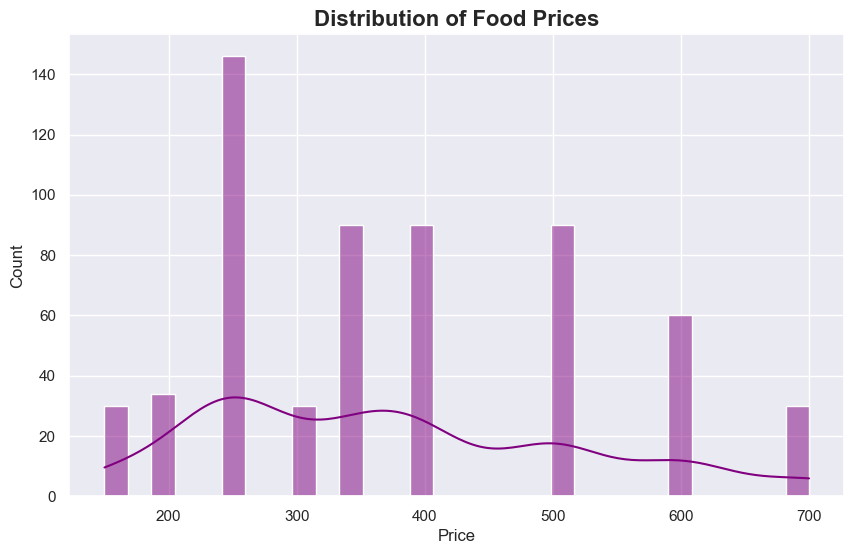

In [25]:
#Price Distribution (Histogram)
plt.figure(figsize=(10,6))

sns.histplot(df["Price"], bins=30, kde=True, color="purple")

plt.title("Distribution of Food Prices", fontsize=16, weight="bold")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

+ The histogram shows the distribution of food prices available in the dataset.
+ The X-axis represents the price of food items, while the Y-axis represents the frequency (count) of items/restaurants.
+ Most food items are concentrated in the ₹300–₹500 price range, indicating moderate pricing across restaurants.
+ Very low-priced and high-priced food items appear less frequently in the dataset.
+ The KDE (Kernel Density Estimation) curve highlights the overall trend and density of food prices.
+ This visualization helps identify the most common price range and understand restaurant pricing patterns on the platform.

**Rating Distribution of food Items**

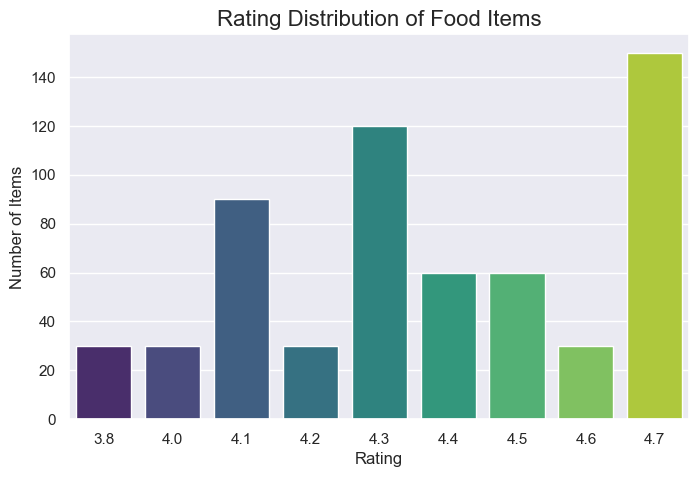

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x="Rating", data=df, palette="viridis")

plt.title("Rating Distribution of Food Items", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Number of Items")

plt.show()

+ The bar chart shows the distribution of ratings assigned to food items in the dataset.
+ The X-axis represents the ratings of food items, while the Y-axis represents the number of food items receiving each rating.
+ Most food items have ratings between 4.3 and 4.7, indicating a high level of customer satisfaction.
+ The highest number of food items are rated 4.7, making it the most common rating in the dataset.
+ Lower ratings such as 3.8 and 4.0 occur less frequently, suggesting that poorly rated food items are relatively uncommon.
+ This visualization helps evaluate overall food quality and understand customer preferences based on ratings.

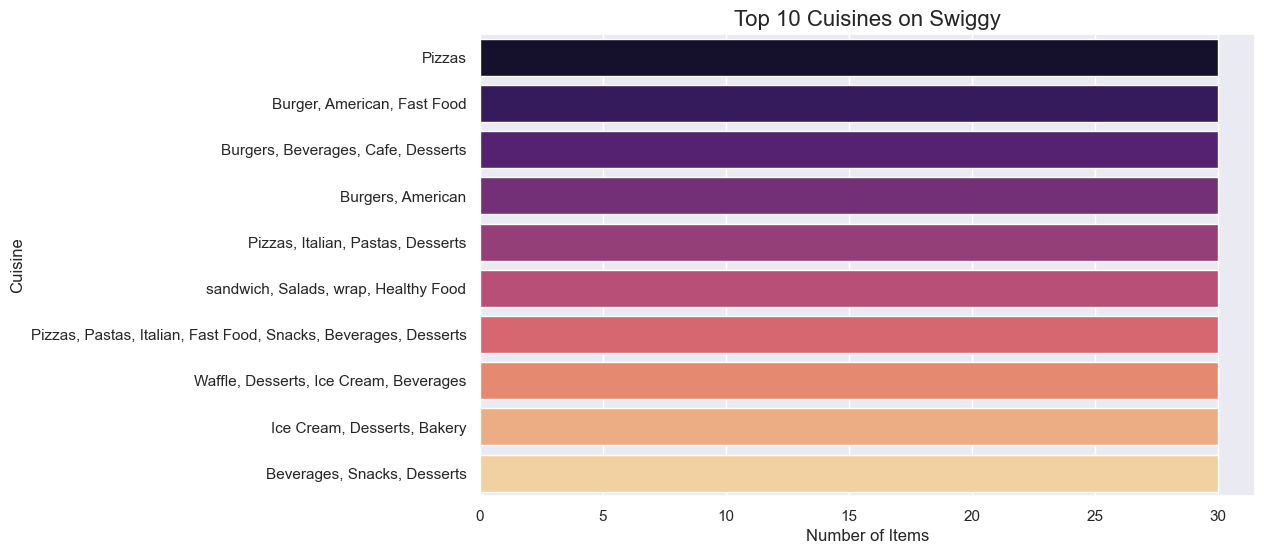

In [23]:
plt.figure(figsize=(10,6))

top_cuisine = df["Cuisine"].value_counts().head(10)

sns.barplot(x=top_cuisine.values, y=top_cuisine.index, palette="magma")

plt.title("Top 10 Cuisines on Swiggy", fontsize=16)
plt.xlabel("Number of Items")
plt.ylabel("Cuisine")

plt.show()

+ The horizontal bar chart displays the top 10 cuisines available in the Swiggy dataset.
+ The X-axis represents the number of food items, while the Y-axis represents different cuisine categories.
+ Pizza-based, Burger-based, Dessert, Beverage, and Fast Food combinations are among the most frequently listed cuisines.
+ The counts of the top cuisines are relatively similar, indicating a diverse variety of food options available on the platform.
+ Multiple cuisine combinations suggest that restaurants often offer a mix of food categories to attract a wider customer base.
+ This visualization helps identify popular cuisine trends and understand customer preferences across different food categories.

**Food Prices**

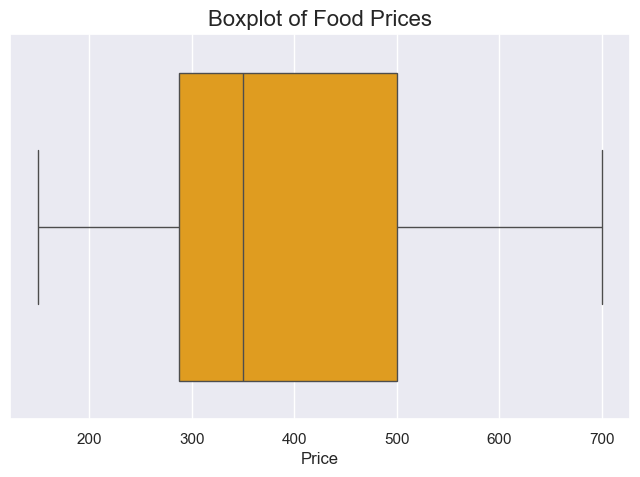

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"], color="orange")

plt.title("Boxplot of Food Prices", fontsize=16)
plt.xlabel("Price")

plt.show()

+ This is a boxplot titled "Boxplot of Food Prices," showing the distribution of food prices ranging roughly from 150 to 700.
+ The median price is around 350, indicated by the vertical line inside the box.
+ The interquartile range (box) spans approximately 290 to 500, representing the middle 50% of prices.
+ The whiskers extend from about 150 to 700, with no visible outliers.

**Price Distribution**

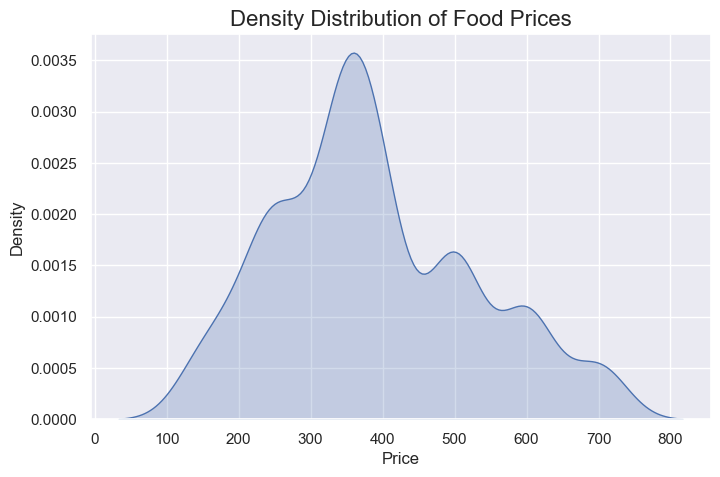

In [25]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["Price"], fill=True)

plt.title("Density Distribution of Food Prices", fontsize=16)
plt.xlabel("Price")
plt.ylabel("Density")

plt.show()

+ The KDE plot shows the smooth distribution of food prices.
+ showing the smoothed probability distribution of food prices from roughly 0 to 800.
+ The distribution is right-skewed with a prominent peak around 350-380, indicating most food items are priced in this range.
+ A smaller secondary peak appears near 500, suggesting a minor cluster of higher-priced items.
+ The density gradually tapers off after 500, with a long tail extending toward 800, representing fewer expensive items.

**Delivery Time Distribution**

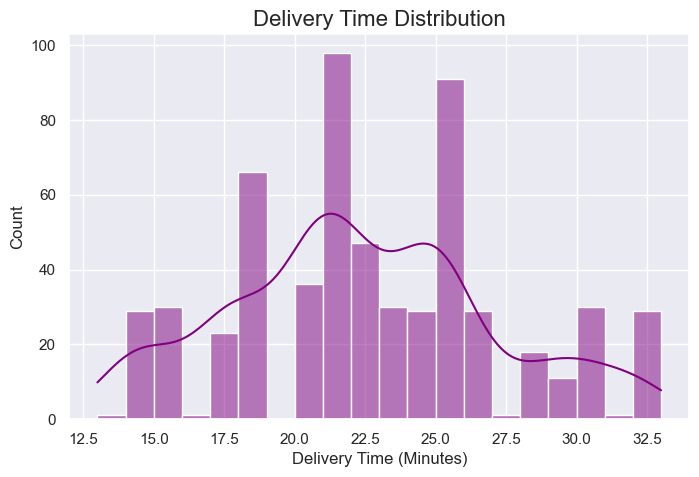

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["Delivery_Time"], bins=20, kde=True, color="purple")

plt.title("Delivery Time Distribution", fontsize=16)
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Count")

plt.show()

+ The histogram shows the distribution of delivery time for food orders.
+ showing the frequency of delivery times ranging from about 12.5 to 33 minutes.
+ Two prominent peaks (modes) appear around 21-22 minutes and 25-26 minutes, each with counts close to 90-100.
+ The KDE curve shows a roughly bimodal pattern, with delivery times concentrated mainly between 18 and 27 minutes.
+ A smaller cluster of deliveries also exists between 30-33 minutes, indicating occasional longer delivery times.

**Top 10 Areas with most Restaurants**

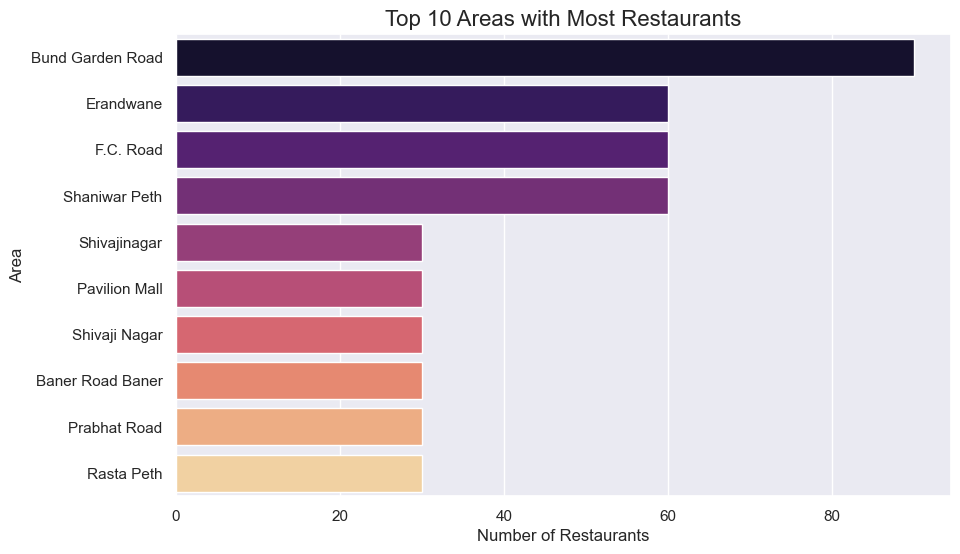

In [27]:
plt.figure(figsize=(10,6))

top_area = df["Area"].value_counts().head(10)

sns.barplot(x=top_area.values, y=top_area.index, palette="magma")

plt.title("Top 10 Areas with Most Restaurants", fontsize=16)
plt.xlabel("Number of Restaurants")
plt.ylabel("Area")

plt.show()

+ The bar plot shows the top 10 areas with the highest number of restaurants in the dataset.
+ ranking areas by the number of restaurants present.
+ Bund Garden Road has the highest count, with around 90 restaurants, significantly ahead of all other areas.
+ Erandwane, F.C. Road, and Shaniwar Peth form the next tier, each with about 60 restaurants.
+ The remaining six areas (Shivajinagar, Pavilion Mall, Shivaji Nagar, Baner Road Baner, Prabhat Road, Rasta Peth) have roughly equal counts of around 30 restaurants each.

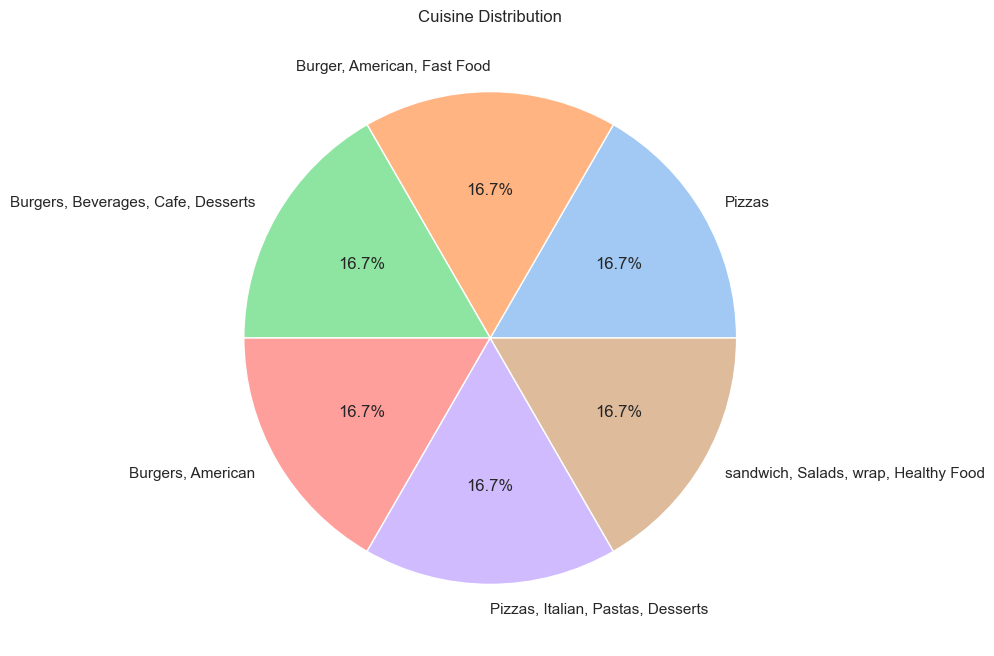

In [28]:
plt.figure(figsize=(8,8))

df["Cuisine"].value_counts().head(6).plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
)

plt.title("Cuisine Distribution")

plt.ylabel("")
plt.show()

+ The pie chart shows the distribution of the top 6 cuisines in the dataset.
+ The chart shows 6 distinct cuisine categories, each occupying an equal share of 16.7% of the total.
+ The categories include combinations like "Pizzas," "Burgers, American," "Burger, American, Fast Food," and "Pizzas, Italian, Pastas, Desserts."
+ The equal distribution suggests this represents the top 6 cuisine types selected from the dataset, each appearing with the same frequency.

 # Bivariate Analysis (Two Variables)

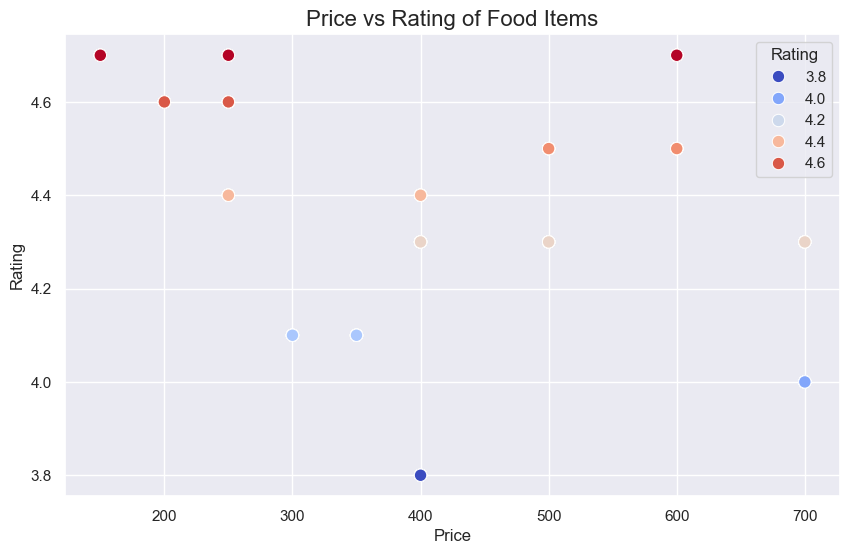

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="Price", y="Rating",
                hue="Rating", palette="coolwarm", s=80)

plt.title("Price vs Rating of Food Items", fontsize=16)
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

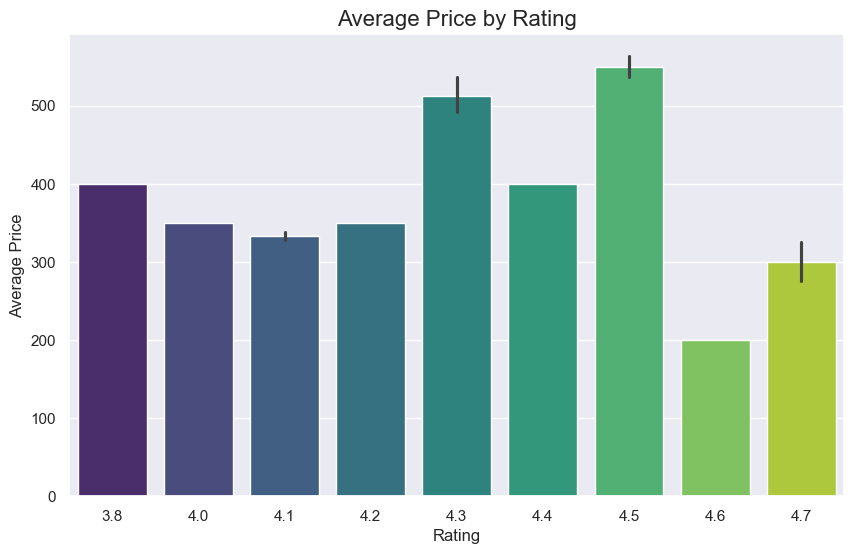

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(x="Rating", y="Price", data=df, palette="viridis")

plt.title("Average Price by Rating", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Average Price")

plt.show()

+ This is a bar chart titled "Average Price by Rating," showing the average food price across different rating values from 3.8 to 4.7.
+ Ratings of 4.5 and 4.3 correspond to the highest average prices, around 550 and 510 respectively, with visible error bars indicating variability.
+ Rating 4.6 has the lowest average price at around 200, despite being a relatively high rating.
+ Overall, there is no clear linear relationship between rating and price, suggesting rating alone doesn't strongly predict cost.

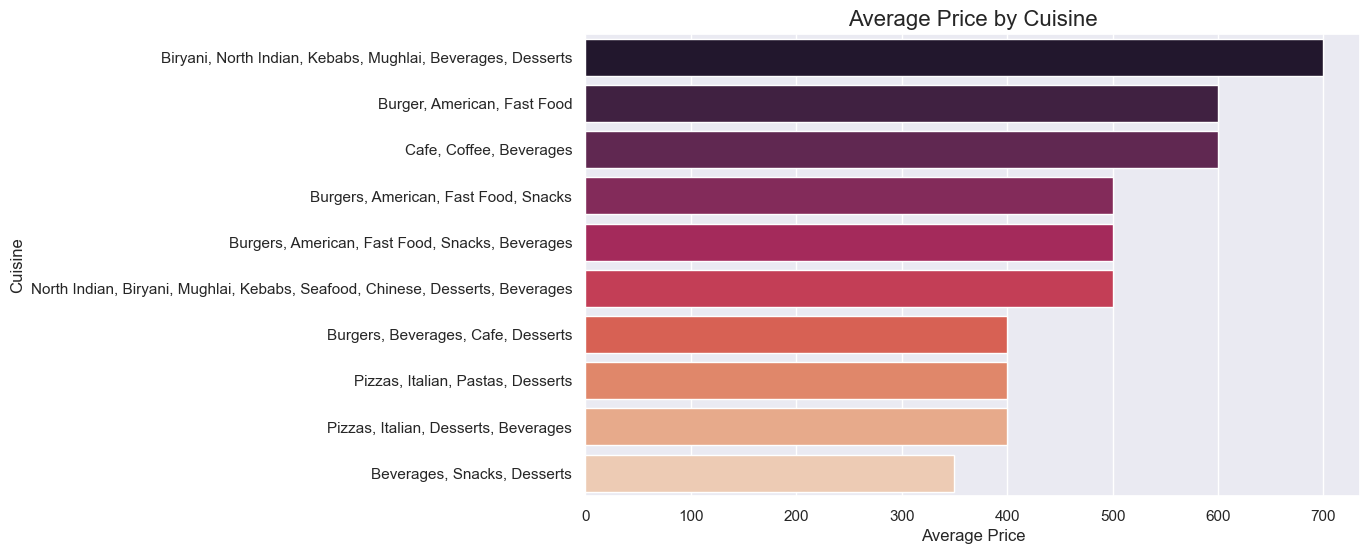

In [31]:
plt.figure(figsize=(10,6))

avg_price = df.groupby("Cuisine")["Price"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=avg_price.values, y=avg_price.index, palette="rocket")

plt.title("Average Price by Cuisine", fontsize=16)
plt.xlabel("Average Price")
plt.ylabel("Cuisine")

plt.show()

+ This is a horizontal bar chart titled "Average Price by Cuisine," ranking cuisine combinations by their average food price.
+ "Biryani, North Indian, Kebabs, Mughlai, Beverages, Desserts" has the highest average price at around 700, the most expensive category.
+ A mid-tier group including "Burger, American, Fast Food," "Cafe, Coffee, Beverages," and similar combinations ranges between 500-600.
+ "Beverages, Snacks, Desserts" has the lowest average price at around 350, indicating these are more budget-friendly cuisine combinations.

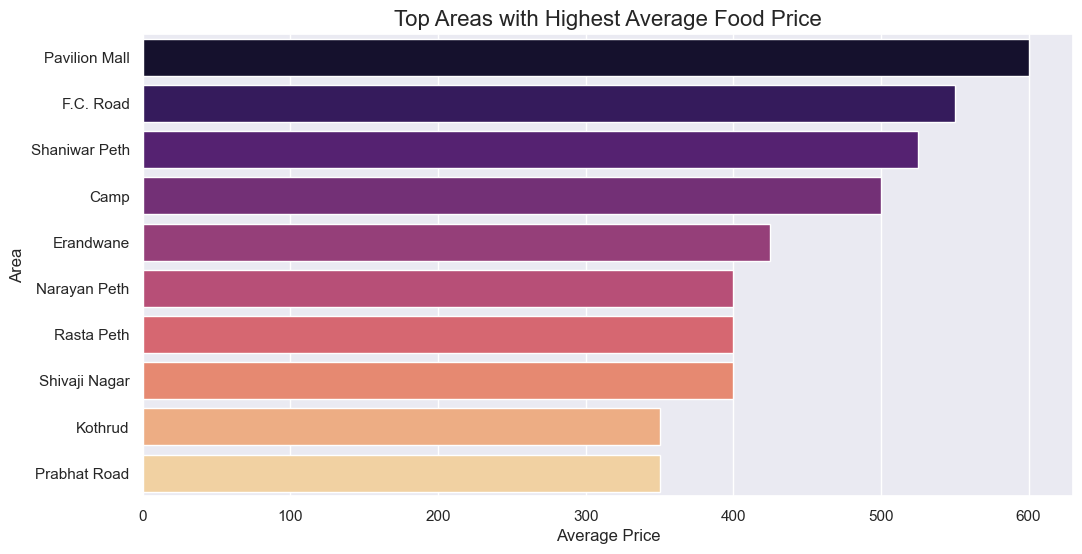

In [32]:
plt.figure(figsize=(12,6))

avg_area_price = df.groupby("Area")["Price"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=avg_area_price.values,
    y=avg_area_price.index,
    palette="magma"
)

plt.title("Top Areas with Highest Average Food Price", fontsize=16)
plt.xlabel("Average Price")
plt.ylabel("Area")

plt.show()

+ This is a horizontal bar chart titled "Top Areas with Highest Average Food Price," ranking areas by their average food cost.
+ Pavilion Mall has the highest average price at around 600, leading all areas.
+ F.C. Road, Shaniwar Peth, and Camp follow closely, with average prices ranging between 500-550.
+ The remaining areas (Erandwane, Narayan Peth, Rasta Peth, Shivaji Nagar, Kothrud, Prabhat Road) have average prices between 350-425, showing a gradual decline toward the bottom of the chart.

# Multivariate Analysis (3+ Variables)

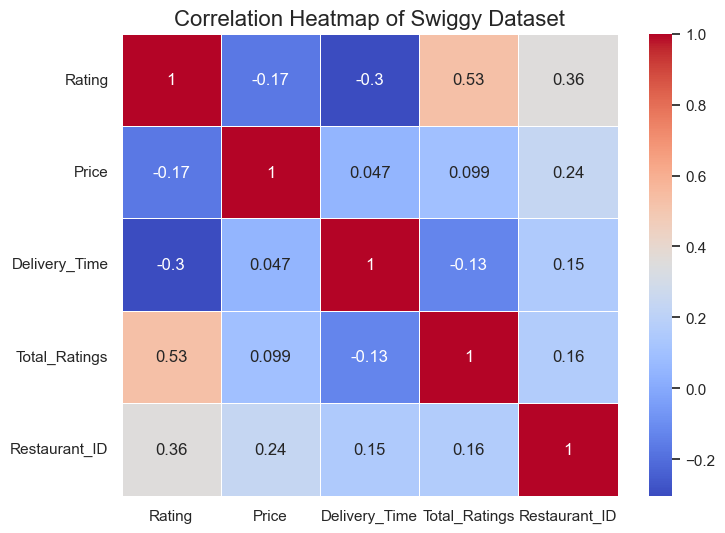

In [33]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap of Swiggy Dataset", fontsize=16)

plt.show()

+ This is a correlation heatmap titled "Correlation Heatmap of Swiggy Dataset," showing pairwise correlation coefficients between numerical variables: Rating, Price, Delivery_Time, Total_Ratings, and Restaurant_ID.
+ Rating and Total_Ratings show a moderate positive correlation of 0.53, suggesting higher-rated restaurants tend to have more ratings.
+ Rating and Delivery_Time show a weak negative correlation of -0.3, indicating slightly faster delivery times may relate to higher ratings.
+ Most other variable pairs (Price, Delivery_Time, Restaurant_ID) show weak correlations close to 0, indicating little to no linear relationship between them.